# Weather Descriptive Analysis -- Part 1 (Sanity Check)

Same logic as the 09 .py script, but rendering figures inline.
Sanity check summary stats only, not polished exhibits (Part 2).

On the Kodama server: run this notebook from `codePYTHON/` (so the relative `dataCSV/` paths below
resolve) with the repo's `.venv` kernel selected.


In [12]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Path: assumes notebook's working directory is codePYTHON/,
# same as the weather pipeline .py scripts.
REPO_ROOT = Path.cwd().resolve().parents[0]
print(f"REPO_ROOT resolved to: {REPO_ROOT}")

ID_COLS = ["geoid", "state_fips", "county_fips", "county_name"]
FIGURES_DIR = REPO_ROOT / "figures" / "weather"
TABLES_DIR = REPO_ROOT / "tables" / "weather"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

WINTER_MONTHS = {12, 1, 2}  # Dec, Jan, Feb

# Proof-of-concept state for the per-county spaghetti plot
PROOF_OF_CONCEPT_STATE_FIPS = "17" # Illinois

# FIPS -> name lookup for figure labels. All 50 states + DC 
# (though PRISM is CONUS only, so 02 + 15 (Alask + Hawaii) 
# will not show up in practice).
STATE_FIPS_TO_NAME = {  
    "01": "Alabama",              "02": "Alaska",                
    "04": "Arizona",              "05": "Arkansas",              
    "06": "California",           "08": "Colorado",              
    "09": "Connecticut",          "10": "Delaware",              
    "11": "District of Columbia", "12": "Florida",               
    "13": "Georgia",              "15": "Hawaii",                
    "16": "Idaho",                "17": "Illinois",              
    "18": "Indiana",              "19": "Iowa",                  
    "20": "Kansas",               "21": "Kentucky",              
    "22": "Louisiana",            "23": "Maine",                 
    "24": "Maryland",             "25": "Massachusetts",         
    "26": "Michigan",             "27": "Minnesota",             
    "28": "Mississippi",          "29": "Missouri",              
    "30": "Montana",              "31": "Nebraska",              
    "32": "Nevada",               "33": "New Hampshire",         
    "34": "New Jersey",           "35": "New Mexico",            
    "36": "New York",             "37": "North Carolina",        
    "38": "North Dakota",         "39": "Ohio",                  
    "40": "Oklahoma",             "41": "Oregon",                
    "42": "Pennsylvania",         "44": "Rhode Island",          
    "45": "South Carolina",       "46": "South Dakota",          
    "47": "Tennessee",            "48": "Texas",                 
    "49": "Utah",                 "50": "Vermont",               
    "51": "Virginia",             "53": "Washington",            
    "54": "West Virginia",        "55": "Wisconsin",             
    "56": "Wyoming",                                             
}  




REPO_ROOT resolved to: /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather


## Dataset selection: PRISM or ERA5

In [13]:
class DatasetConfig:
    """Per-dataset paths, mirroring 06_build_derived_weather_vars.py's
    DatasetConfig pattern so PRISM/ERA5 run through identical logic."""

    def __init__(self, name, monthly_path, derived_path, is_primary=False):
        self.name = name
        self.monthly_path = monthly_path
        self.derived_path = derived_path
        self.is_primary = is_primary # PRISM is primary


PRISM_CONFIG = DatasetConfig(
    name="PRISM",
    monthly_path=REPO_ROOT / "dataCSV" / "PRISM" / "prism_county_month.csv",
    derived_path=REPO_ROOT / "dataCSV" / "PRISM" / "prism_derived_weather_vars.csv",
    is_primary=True,
)

ERA5_CONFIG = DatasetConfig(
    name="ERA5",
    monthly_path=REPO_ROOT / "dataCSV" / "ERA5" / "era5_county_month.csv",
    derived_path=REPO_ROOT / "dataCSV" / "ERA5" / "era5_derived_weather_vars.csv",
    is_primary=False,
)

config = PRISM_CONFIG
print(f"Using dataset: {config.name}")
print(f"  monthly_path: {config.monthly_path}")
print(f"  derived_path: {config.derived_path}")

Using dataset: PRISM
  monthly_path: /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/dataCSV/PRISM/prism_county_month.csv
  derived_path: /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/dataCSV/PRISM/prism_derived_weather_vars.csv


## Load + merge the county-year-month panel

Merges 05's raw monthly means with 06's derived vars, on `geoid + year + month`.

In [14]:
def load_weather_panel(config: DatasetConfig) -> pd.DataFrame:
    """Merge 05's raw monthly means with 06's derived vars into one
    county-year-month panel, keyed on geoid + year + month.

    Merging on geoid alone (not the full ID_COLS) is deliberate: geoid
    already uniquely identifies a county, and merging on the free-text
    county_name too risks a silent non-match from a formatting difference
    between the two scripts' outputs. monthly's copies of state_fips/
    county_fips/county_name are kept as canonical; derived's are dropped.
    """
    dtype = {"geoid": str, "state_fips": str, "county_fips": str}

    print(f"Loading {config.name} monthly panel from:\n  {config.monthly_path}")
    monthly = pd.read_csv(config.monthly_path, dtype=dtype)
    print(f"  {len(monthly):,} rows.")

    print(f"Loading {config.name} derived weather vars from:\n  {config.derived_path}")
    derived = pd.read_csv(config.derived_path, dtype=dtype)
    print(f"  {len(derived):,} rows.")

    merge_keys = ["geoid", "year", "month"]
    redundant_id_cols = [c for c in ID_COLS if c != "geoid"]

    # 05 and 06 both independently compute n_days/expected_days/
    # is_incomplete[/dataset_types for PRISM] from the same daily source --
    # check they agree before dropping derived's copies, so a silent
    # divergence between the two scripts doesn't go unnoticed.
    qa_cols = [
        c for c in ("n_days", "expected_days", "is_incomplete", "dataset_types")
        if c in monthly.columns and c in derived.columns
    ]
    if qa_cols:
        check = monthly[merge_keys + qa_cols].merge(
            derived[merge_keys + qa_cols], on=merge_keys, suffixes=("_monthly", "_derived")
        )
        for col in qa_cols:
            mismatched = check[f"{col}_monthly"] != check[f"{col}_derived"]
            if mismatched.any():
                print(
                    f"  Warning: {mismatched.sum():,} row(s) where '{col}' "
                    f"disagrees between the monthly and derived {config.name} "
                    "files -- investigate before trusting either QA column."
                )

    derived_slim = derived.drop(columns=redundant_id_cols + qa_cols)

    merged = monthly.merge(
        derived_slim, on=merge_keys, how="outer", indicator=True, validate="one_to_one"
    )

    unmatched = merged[merged["_merge"] != "both"]
    if not unmatched.empty:
        print(
            f"  Warning: {len(unmatched):,} county-month row(s) present in only "
            f"one of the monthly/derived {config.name} files -- see the "
            "'_merge' column before treating this panel as complete."
        )
    merged = merged.drop(columns="_merge")

    print(
        f"  Merged panel: {len(merged):,} county-month rows, "
        f"{merged['geoid'].nunique():,} counties, "
        f"{merged['year'].nunique()} year(s) "
        f"({merged['year'].min()}-{merged['year'].max()})."
    )
    return merged


df = load_weather_panel(config)
df.head()

Loading PRISM monthly panel from:
  /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/dataCSV/PRISM/prism_county_month.csv
  1,678,320 rows.
Loading PRISM derived weather vars from:
  /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/dataCSV/PRISM/prism_derived_weather_vars.csv
  1,678,320 rows.
  Merged panel: 1,678,320 county-month rows, 3,108 counties, 45 year(s) (1981-2025).


,geoid,state_fips,county_fips,county_name,year,month,n_days,ppt_total,tmean_mean,tmin_mean,...,days_extremely_cold,days_below_freezing_32f,freeze_thaw_days,days_precip_above_10mm,heating_degree_days,cooling_degree_days,mean_temp_c,tmean_variance_c2,tmin_variance_c2,tmax_variance_c2
0,01001,01,001,Autauga,1981,1,31,41.513720,4.920923,-1.935180,...,0,24,24,2,415.784727,0.000000,4.920923,15.670304,16.432242,25.617245
1,01001,01,001,Autauga,1981,2,28,183.999778,9.292531,2.905967,...,0,10,10,4,253.142454,0.000000,9.292531,41.704790,40.800833,53.746903
2,01001,01,001,Autauga,1981,3,31,243.287245,11.805146,4.266983,...,0,0,0,6,205.044105,2.670284,11.805146,10.924556,14.085494,12.941082
3,01001,01,001,Autauga,1981,4,30,39.155931,19.964888,13.403788,...,0,0,0,2,14.868339,63.814984,19.964888,6.759448,9.827021,6.742854
4,01001,01,001,Autauga,1981,5,31,81.438487,20.525748,14.197903,...,0,0,0,3,14.218969,82.183816,20.525748,10.196204,11.408056,12.894266


## Winter-year construction

December belongs to the *following* winter_year; Jan/Feb belong to their own calendar year's winter_year (e.g. Dec 2020 + Jan 2021 + Feb 2021 -> `winter_year == 2021`).

**TODO:** confirm this matches whatever convention Nicole's population-regression side assumes (the "handshake" between the weather and wildlife sides).

In [15]:
def add_winter_year(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["winter_year"] = df["year"] + (df["month"] == 12).astype(int)
    return df


def restrict_to_winter(df: pd.DataFrame, complete_only: bool = True) -> pd.DataFrame:
    """Filter to Dec/Jan/Feb rows - most Phase 4 exhibits are winter-only.

    complete_only=True (default) also drops the boundary winter_year(s)
    that can't have all 3 months present for a given county: the panel's
    very first winter_year has Jan/Feb only (no preceding Dec), and its
    very last has Dec only (no following Jan/Feb). Left in, those show up
    as partial "winters" on a trend/spaghetti plot - e.g. a single Dec
    reading plotted as if it were a full winter mean, which reads as a
    misleading jump. Mirrors 05/06's convention of flagging incompleteness
    rather than silently averaging over it.
    """
    winter = df[df["month"].isin(WINTER_MONTHS)].copy()
    if not complete_only:
        return winter

    winter["_n_months_in_winter"] = winter.groupby(["geoid", "winter_year"])["month"].transform("nunique")
    incomplete_years = sorted(int(y) for y in winter.loc[winter["_n_months_in_winter"] < 3, "winter_year"].unique())
    if incomplete_years:
        print(
            f"  Note: dropping partial-winter row(s) for winter_year(s) "
            f"{incomplete_years} - missing Dec and/or Jan/Feb at the panel's "
            "date boundary."
        )
    return winter[winter["_n_months_in_winter"] == 3].drop(columns="_n_months_in_winter")


df = add_winter_year(df)
winter = restrict_to_winter(df)
print(f"Winter-restricted panel: {len(winter):,} rows, winter_year range {winter['winter_year'].min()}-{winter['winter_year'].max()}")

  Note: dropping partial-winter row(s) for winter_year(s) [1981, 2026] - missing Dec and/or Jan/Feb at the panel's date boundary.
Winter-restricted panel: 410,256 rows, winter_year range 1982-2025


## Summary statistics tables

Summary statistics tables for all weather variables, by county, by month, and pooled (all counties, months, years collapsed into a single mean/sd/min/max/n per variable).
To see where the variation comes from, before the regressions.

In [16]:
_NON_WEATHER_COLS = {
    *ID_COLS, "year", "month", "winter_year",
    "n_days", "expected_days", "is_incomplete", "dataset_types",
}


def _weather_variable_columns(df: pd.DataFrame) -> list:
    """Every numeric column that isn't an ID/year/month/QA column."""
    return [
        c for c in df.columns
        if c not in _NON_WEATHER_COLS and pd.api.types.is_numeric_dtype(df[c])
    ]


def summary_stats_table(df: pd.DataFrame, by=None) -> pd.DataFrame:
    """One row per weather variable (by=None, pooled) or one row per
    group x variable (by="county" -> geoid, by="month" -> month):
    mean / sd / min / max / n.
    """
    variables = _weather_variable_columns(df)

    if by is None:
        stats = df[variables].agg(["mean", "std", "min", "max", "count"]).T
        stats.index.name = "variable"
        return stats.reset_index()

    group_col = {"county": "geoid", "month": "month"}.get(by)
    if group_col is None:
        raise ValueError(f"Unsupported `by` value: {by!r} (expected None, 'county', or 'month')")

    grouped = df.groupby(group_col)[variables].agg(["mean", "std", "min", "max", "count"])
    grouped.columns = [f"{var}_{stat}" for var, stat in grouped.columns]
    return grouped.reset_index()

In [17]:
summary_pooled = summary_stats_table(df, by=None)
summary_pooled.to_csv(TABLES_DIR / f"{config.name.lower()}_summary_pooled.csv", index=False)
summary_pooled

,variable,mean,std,min,max,count
0,ppt_total,84.113505,63.442325,0.000000,1282.292877,1678320.0
1,tmean_mean,12.574239,9.883187,-25.086144,36.389163,1678320.0
2,tmin_mean,6.427151,9.668881,-31.218806,28.952674,1678320.0
3,tmax_mean,18.721636,10.243949,-19.476206,44.150934,1678320.0
4,tdmean_mean,6.306368,9.520643,-28.674932,25.848308,1678320.0
5,vpdmin_mean,1.078322,1.174098,0.000000,25.170275,1678320.0
6,vpdmax_mean,14.443675,8.847299,0.405437,77.406020,1678320.0
7,days_extremely_cold,0.557025,2.322020,0.000000,31.000000,1678320.0
8,days_below_freezing_32f,8.684700,10.936999,0.000000,31.000000,1678320.0
9,freeze_thaw_days,6.682357,8.269132,0.000000,31.000000,1678320.0


In [18]:
summary_by_month = summary_stats_table(df, by="month")
summary_by_month.to_csv(TABLES_DIR / f"{config.name.lower()}_summary_by_month.csv", index=False)
summary_by_month

,month,ppt_total_mean,ppt_total_std,ppt_total_min,ppt_total_max,ppt_total_count,tmean_mean_mean,tmean_mean_std,tmean_mean_min,tmean_mean_max,...,tmin_variance_c2_mean,tmin_variance_c2_std,tmin_variance_c2_min,tmin_variance_c2_max,tmin_variance_c2_count,tmax_variance_c2_mean,tmax_variance_c2_std,tmax_variance_c2_min,tmax_variance_c2_max,tmax_variance_c2_count
0,1,69.302086,63.658517,0.0,908.594720,139860,0.247689,6.688056,-25.086144,22.475813,...,32.111103,19.126775,0.822870,183.712031,139860,35.505357,18.782846,1.010423,169.934112,139860
1,2,69.017213,62.085681,0.0,878.314950,139860,2.208621,6.933573,-21.934184,24.088524,...,30.297499,19.953807,0.886720,177.572370,139860,39.260379,24.517646,1.007986,167.287058,139860
2,3,82.591211,59.981088,0.0,799.132911,139860,7.035049,5.930876,-12.975760,24.966798,...,25.177416,14.493506,0.813096,165.643025,139860,36.463455,19.065061,0.842394,158.713126,139860
3,4,87.393967,58.240780,0.0,560.501653,139860,12.191453,4.986970,-5.338637,27.484400,...,19.133104,8.688054,0.539607,69.792588,139860,31.326232,16.564372,0.363154,115.717403,139860
4,5,102.051628,62.080106,0.0,669.607812,139860,17.445293,4.385861,0.442680,30.810848,...,14.588417,7.111956,0.321604,50.790463,139860,21.039503,11.959061,0.088131,91.304568,139860
5,6,101.310291,62.964078,0.0,690.033564,139860,22.060459,3.896982,5.751523,32.939180,...,8.654645,4.823991,0.199685,38.458241,139860,12.686786,8.368374,0.239845,72.851511,139860
6,7,97.086704,62.135190,0.0,589.672246,139860,24.272440,3.340049,8.801275,36.389163,...,5.239861,3.512114,0.104567,27.562682,139860,8.011401,5.102229,0.077850,44.964624,139860
7,8,89.200953,61.423424,0.0,1282.292877,139860,23.460538,3.527712,8.837921,35.753046,...,6.527249,4.429976,0.154975,33.029461,139860,9.044264,5.843970,0.201862,61.125108,139860
8,9,81.873989,63.796621,0.0,799.479409,139860,19.590810,4.018549,3.910280,31.617378,...,15.169419,8.511322,0.189454,59.259737,139860,18.165168,12.220360,0.125495,101.614136,139860
9,10,78.394026,61.132394,0.0,842.132993,139860,13.347011,4.641248,-3.271588,28.212494,...,20.778201,9.800540,0.408157,94.655053,139860,27.262001,16.166978,0.325215,157.078941,139860


In [19]:
summary_by_county = summary_stats_table(df, by="county")
summary_by_county.to_csv(TABLES_DIR / f"{config.name.lower()}_summary_by_county.csv", index=False)
print(f"{len(summary_by_county):,} counties -- showing first 10:")
summary_by_county.head(10)

3,108 counties -- showing first 10:


,geoid,ppt_total_mean,ppt_total_std,ppt_total_min,ppt_total_max,ppt_total_count,tmean_mean_mean,tmean_mean_std,tmean_mean_min,tmean_mean_max,...,tmin_variance_c2_mean,tmin_variance_c2_std,tmin_variance_c2_min,tmin_variance_c2_max,tmin_variance_c2_count,tmax_variance_c2_mean,tmax_variance_c2_std,tmax_variance_c2_min,tmax_variance_c2_max,tmax_variance_c2_count
0,01001,116.578497,61.500759,0.138508,352.068539,540,18.034015,7.157152,3.118744,29.794824,...,18.050167,13.706203,0.290545,75.946536,540,16.503463,12.771109,0.943745,88.487942,540
1,01003,139.304523,84.040561,0.286385,607.926233,540,19.554471,6.426871,6.084388,29.948108,...,17.048877,13.816227,0.277689,73.773172,540,11.762684,10.117958,0.905059,56.567112,540
2,01005,111.597339,65.741163,0.143061,476.303269,540,18.316862,6.817660,3.916100,28.878512,...,17.586821,13.280573,0.301621,67.409417,540,15.294087,11.412290,0.854063,64.031436,540
3,01007,117.879344,60.452244,2.591531,341.579837,540,17.374295,7.385768,1.897975,29.759150,...,19.280706,14.392419,0.202395,85.780971,540,17.600406,13.626341,1.115093,95.264606,540
4,01009,121.921574,61.210941,0.536510,361.966360,540,16.086723,7.584176,0.356501,28.768471,...,19.017873,13.411177,0.464059,81.897032,540,18.960308,14.052745,1.353033,96.794130,540
5,01011,113.891359,63.992061,3.730389,390.608344,540,17.889406,6.928580,3.188598,28.704901,...,18.585280,13.853422,0.390919,69.187220,540,15.806599,12.048094,0.667066,75.619132,540
6,01013,123.052856,67.557679,0.138710,490.863223,540,18.209178,6.864508,3.754534,28.632489,...,18.794303,14.345195,0.204068,74.893230,540,15.534885,12.357097,1.315741,79.349929,540
7,01015,115.979730,57.847092,0.045166,316.326237,540,16.182918,7.476652,0.849570,28.548395,...,18.904318,13.144493,0.369993,74.445715,540,18.118635,13.076600,1.045809,91.281105,540
8,01017,111.617728,60.431905,0.091399,380.120084,540,16.793532,7.202457,2.472153,28.411798,...,18.443922,13.167788,0.351139,71.510532,540,16.217705,11.757712,1.316467,81.293686,540
9,01019,115.455401,57.060592,0.976561,321.649148,540,15.703993,7.678988,-0.190086,28.478618,...,18.627985,12.753552,0.360054,66.487429,540,18.524916,12.905882,1.323943,88.573724,540


## Trend figures

National + state-level winter trends for mean temperature, days below 32°F (road-conditions covariate), and freeze-thaw days.

In [ ]:
def state_panel_label(state_fips) -> str:  
    """Panel title for one state: '17 - Illinois'.

    Normalizes to a zero-padded 2-char string first, so a panel still gets
    labelled if some upstream read drops the dtype={'state_fips': str} and
    pandas hands back an int (1 -> '01'). An unrecognized code falls back
    to the bare code plus a marker rather than raising - a mislabelled
    sanity-check panel is recoverable, a crashed figure loop is noise.
    """
    code = str(state_fips).zfill(2)  
    name = STATE_FIPS_TO_NAME.get(code)  
    return f"{code} - {name}" if name else f"{code} - (unmapped)"  

def _set_year_axis_limits(ax, year_values):
    """Explicit x-limits with padding -- matplotlib's autoscale on a
    single distinct x-value (as with a short test panel) otherwise
    defaults to a huge, unreadable date-like range.
    """
    year_min, year_max = year_values.min(), year_values.max()
    pad = max(1, round(0.05 * (year_max - year_min)))
    ax.set_xlim(year_min - pad, year_max + pad)


def plot_national_trend(df: pd.DataFrame, variable: str, dataset_name: str, year_col: str = "winter_year"):
    national = df.groupby(year_col)[variable].mean().reset_index()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(national[year_col], national[variable], marker="o", markersize=4, linewidth=1)
    _set_year_axis_limits(ax, national[year_col])
    ax.set_xlabel(year_col.replace("_", " ").title())
    ax.set_ylabel(variable)
    ax.set_title(f"[{dataset_name}] National mean {variable} by {year_col}")

    out_path = FIGURES_DIR / f"{dataset_name.lower()}_sanity_national_trend_{variable}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  Saved {out_path}")
    # (no plt.close() here -- leaving the figure open lets %matplotlib inline
    # render it below the cell, unlike the .py script's batch version.)


def plot_state_small_multiples(df, variable: str, dataset_name: str, year_col: str = "winter_year"):
    state_year = df.groupby(["state_fips", year_col])[variable].mean().reset_index()
    states = sorted(state_year["state_fips"].unique())
    n_states = len(states)

    n_cols = 6
    n_rows = -(-n_states // n_cols)  # ceil division
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(2.4 * n_cols, 1.8 * n_rows), sharex=True, sharey=True
    )
    axes = axes.flatten()

    for ax, state in zip(axes, states):
        sub = state_year[state_year["state_fips"] == state]
        ax.plot(sub[year_col], sub[variable], marker="o", markersize=2, linewidth=1)
        ax.set_title(state_panel_label(state), fontsize=7)
        ax.tick_params(labelsize=6)

    _set_year_axis_limits(axes[0], state_year[year_col])  # shared axes -- setting one propagates

    for ax in axes[n_states:]:
        ax.axis("off")

    fig.suptitle(f"[{dataset_name}] State-level mean {variable} by {year_col}")
    fig.tight_layout()

    out_path = FIGURES_DIR / f"{dataset_name.lower()}_sanity_state_small_multiples_{variable}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  Saved {out_path}")

def plot_county_spaghetti(
    df: pd.DataFrame,
    variable: str,
    state_fips: str,
    dataset_name: str,
    year_col: str = "winter_year",
    ax=None,
):
    """Per 8/18 meeting, refined per Eyal's 8/25 Slack follow-up: one
    trend line per county within a state, with county lines drawn thin/
    transparent and a bold state-level mean line overlaid on top so the
    overall trend doesn't get lost in the spread (the same idea from his
    infant-mortality spaghetti-plot example on the 8/25 call). See also
    plot_county_spaghetti_multi_panel below, which ports his Stata
    `by(state_letter_code)` one-liner to a Python small-multiples layout.

    Pass `ax` to draw into an existing Axes instead of creating/saving a
    standalone figure -- lets plot_county_spaghetti_multi_panel reuse
    this same per-state drawing logic for each of its subplots.
    """
    state_df = df[df["state_fips"] == state_fips]
    if state_df.empty:
        raise ValueError(f"No rows found for state_fips={state_fips!r}")

    county_year = state_df.groupby(["geoid", year_col])[variable].mean().reset_index()
    state_year = state_df.groupby(year_col)[variable].mean().reset_index()
    n_counties = county_year["geoid"].nunique()

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 5))

    for _, sub in county_year.groupby("geoid"):
        # Small markers matter here, not just the line -- with a short
        # test panel (e.g. today's 2-year PRISM sample), a county can
        # have only one winter_year value, and a lone point is invisible
        # without a marker even though the line itself is drawn thin.
        ax.plot(
            sub[year_col], sub[variable],
            marker="o", markersize=1.5, linewidth=0.4, alpha=0.3,
            color="steelblue", zorder=1,
        )
    ax.plot(
        state_year[year_col], state_year[variable],
        marker="o", markersize=4, linewidth=2.2, alpha=1.0,
        color="black", zorder=2, label="State mean",
    )
    _set_year_axis_limits(ax, county_year[year_col])

    if standalone:
        ax.set_xlabel(year_col.replace("_", " ").title())
        ax.set_ylabel(variable)
        ax.set_title(
            f"[{dataset_name}] {variable} by county, state_fips={state_fips} "
            f"({n_counties} counties) -- SANITY CHECK, unstyled"
        )
        ax.legend(fontsize=8, loc="best")

        out_path = FIGURES_DIR / f"{dataset_name.lower()}_sanity_county_spaghetti_{variable}_state{state_fips}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"  Saved {out_path}")
        return out_path
    else:
        ax.set_title(f"{state_panel_label(state_fips)} (n={n_counties})", fontsize=7)
        return n_counties

  Saved /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/figures/weather/prism_sanity_national_trend_mean_temp_c.png
  Saved /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/figures/weather/prism_sanity_state_small_multiples_mean_temp_c.png
  Saved /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/figures/weather/prism_sanity_national_trend_days_extremely_cold.png
  Saved /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/figures/weather/prism_sanity_state_small_multiples_days_extremely_cold.png
  Saved /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/figures/weather/prism_sanity_national_trend_days_below_freezing_32f.png
  Saved /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/figures/weather/prism_sanity_state_small_multiples_days_below_freezing_32f.png
  Saved /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/figures/weather/prism_sanity_national_trend_freeze_thaw_days.png
  Saved /mnt/data_d/Dropbox/Research/AnimalCollisionsWeather/figures/weather/prism_sani

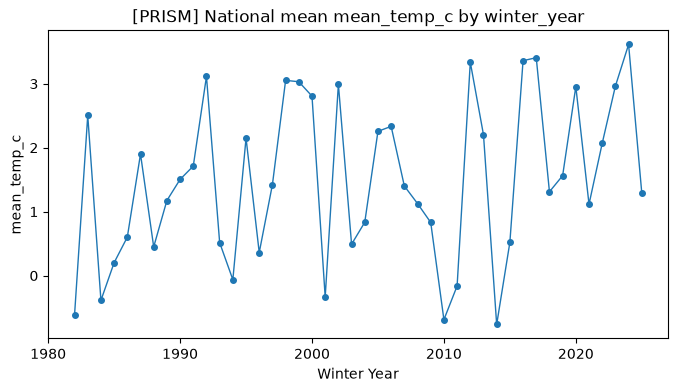

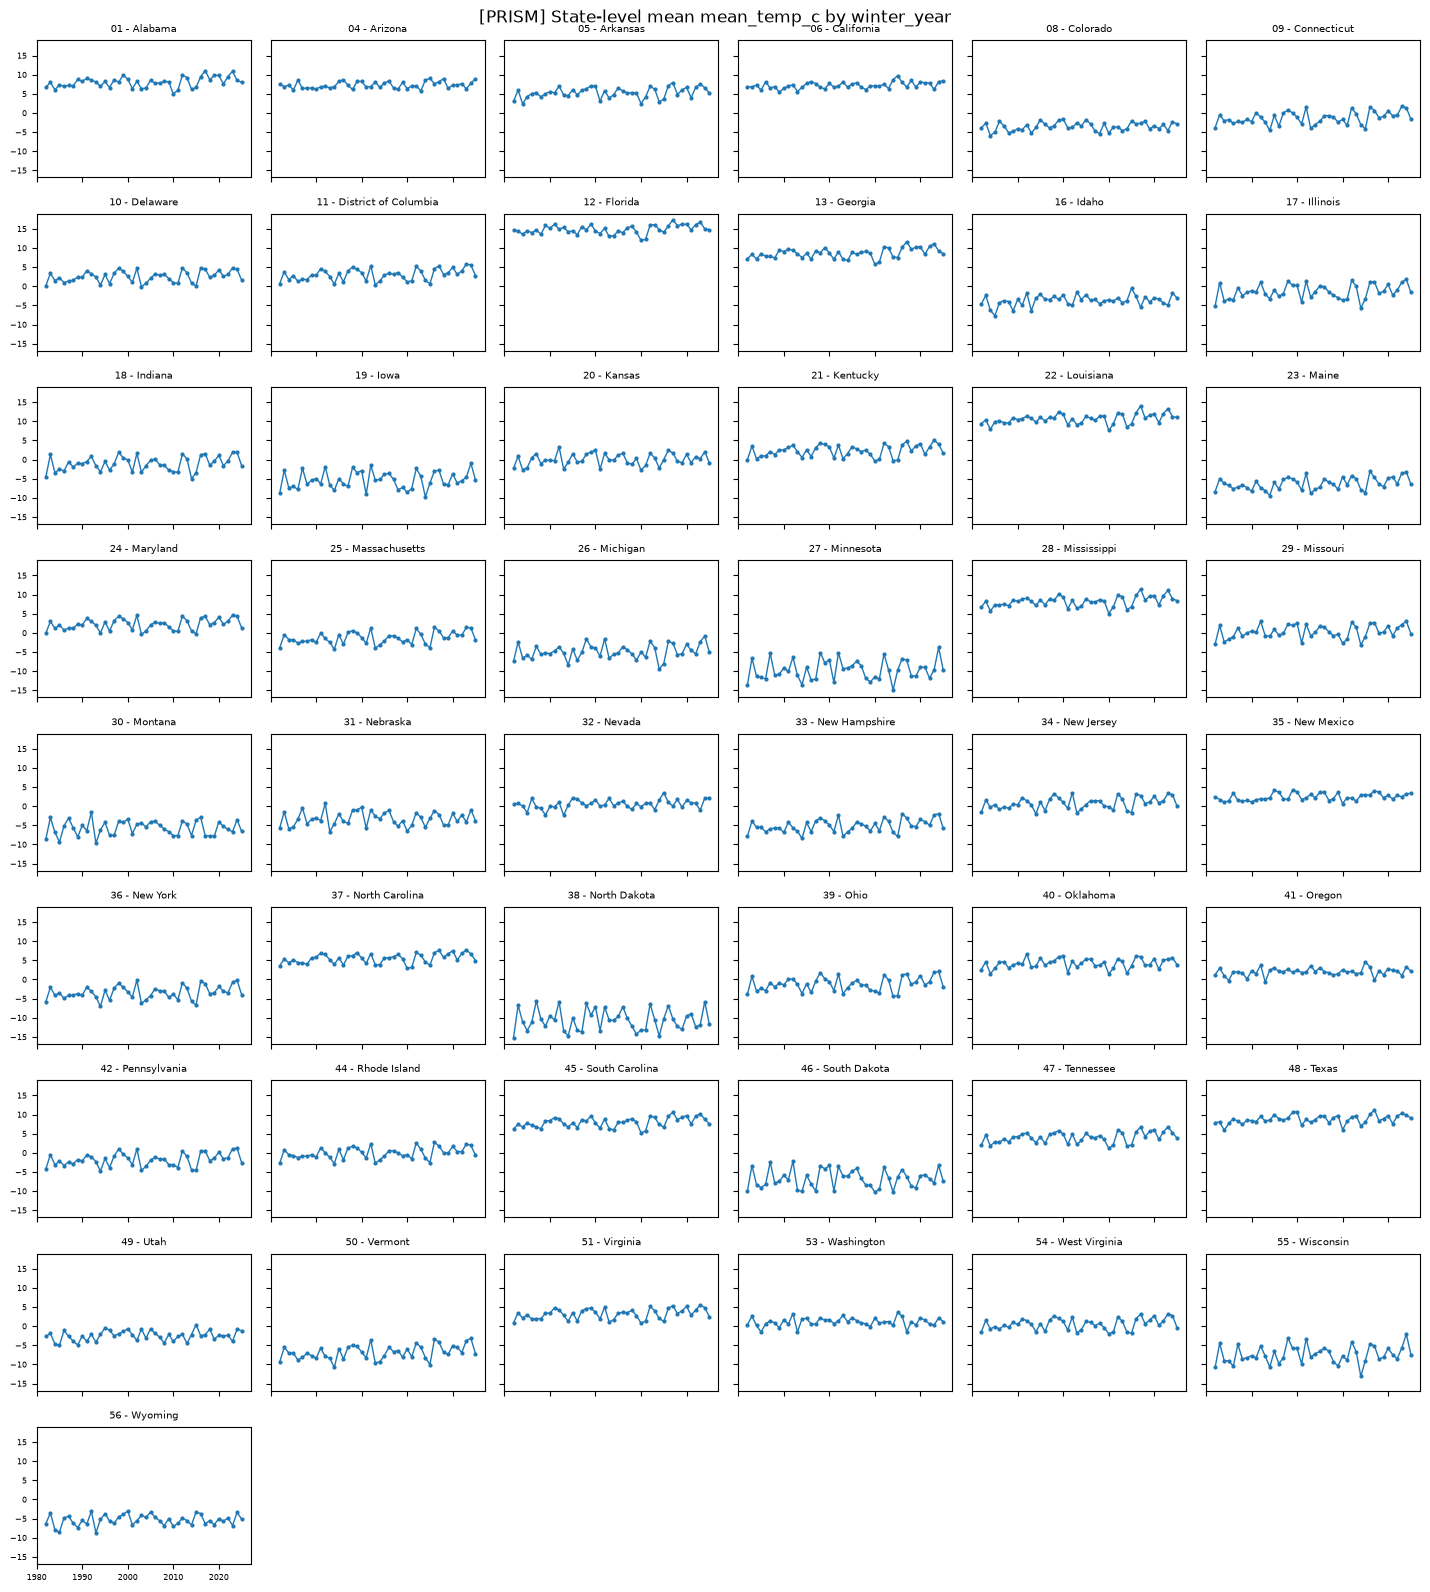

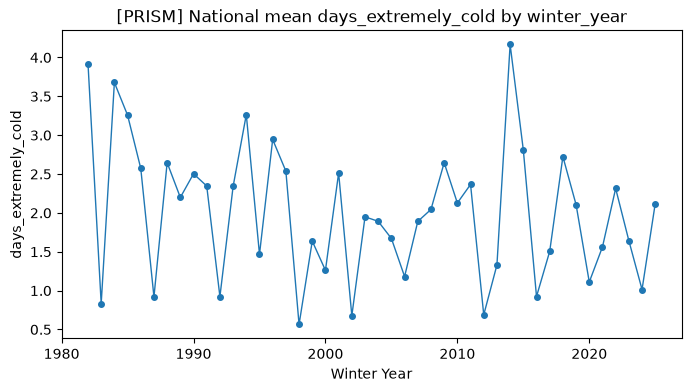

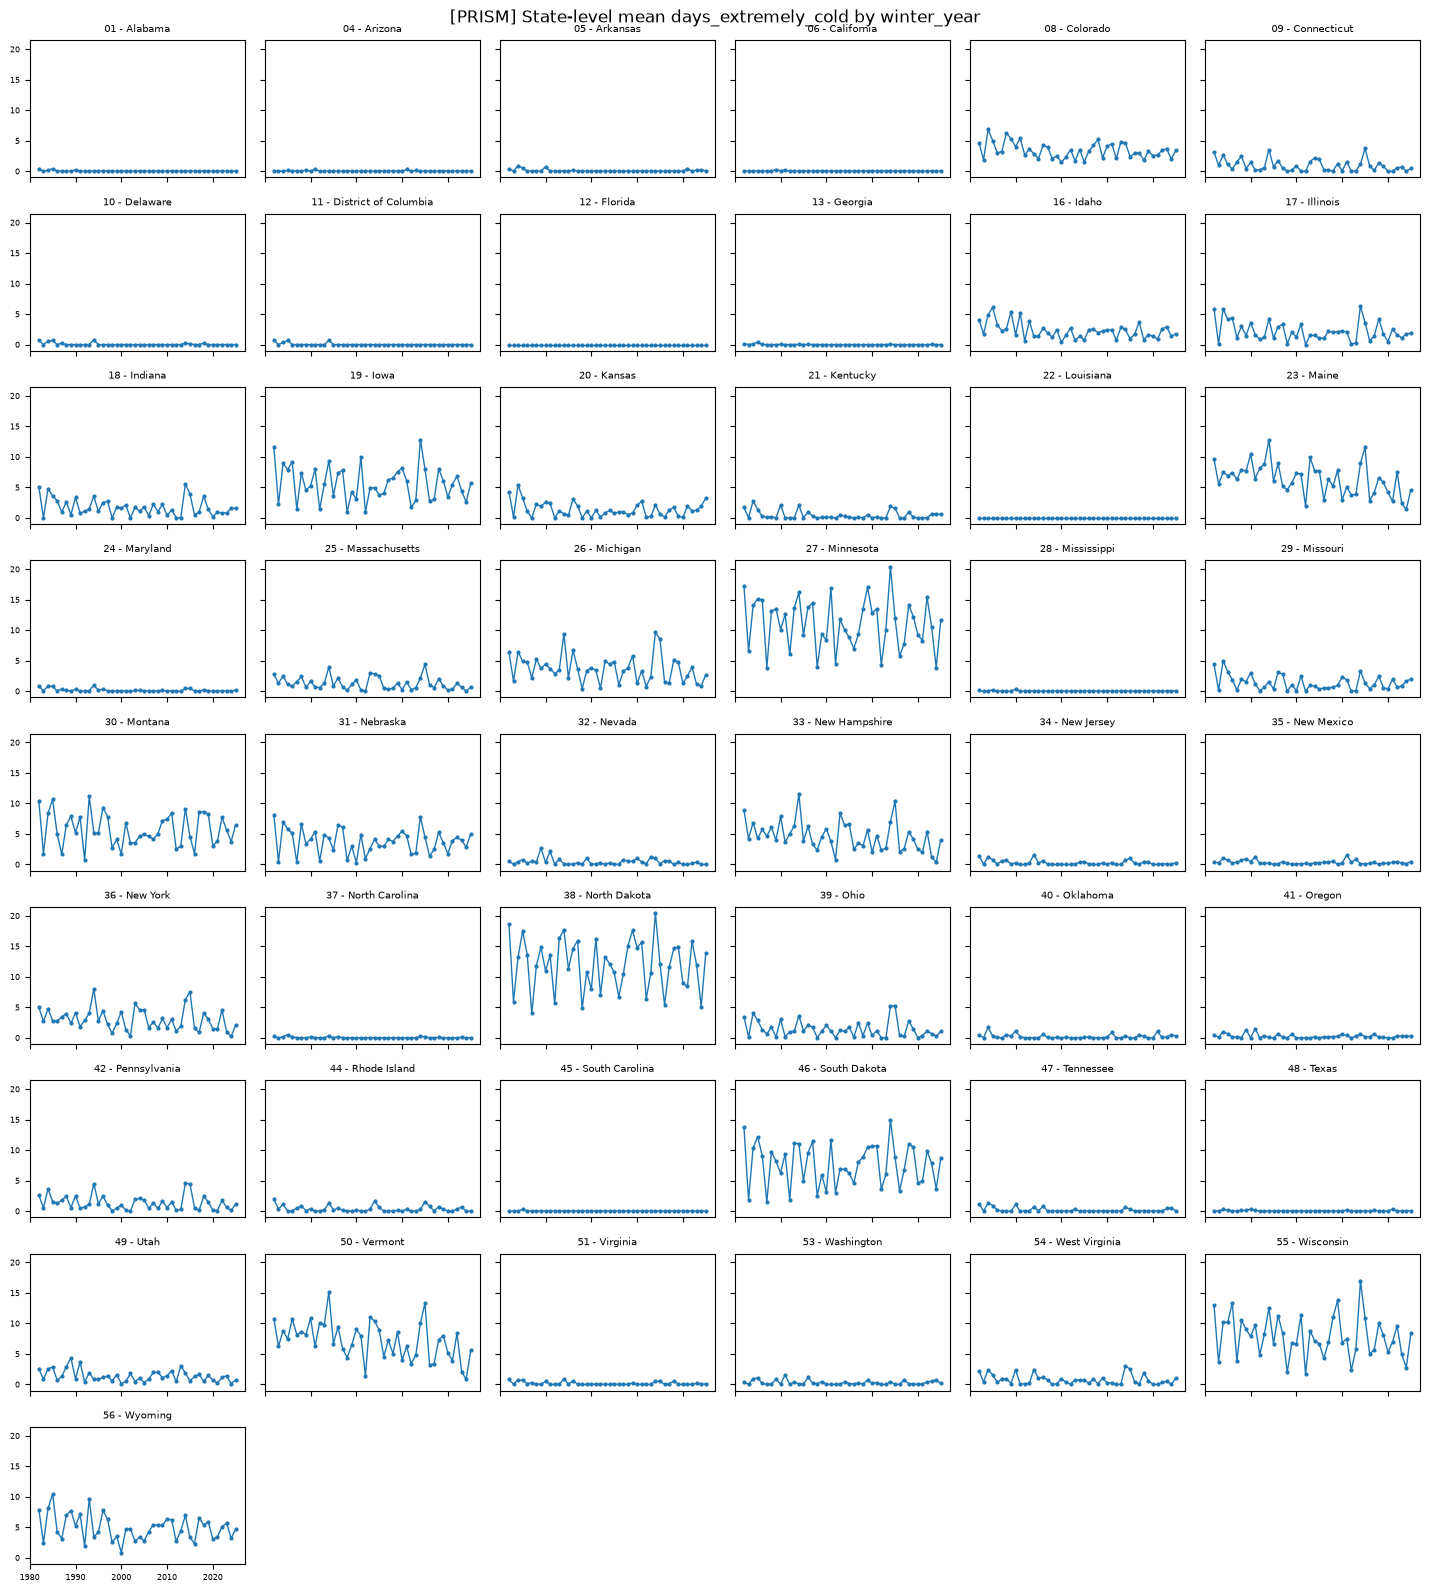

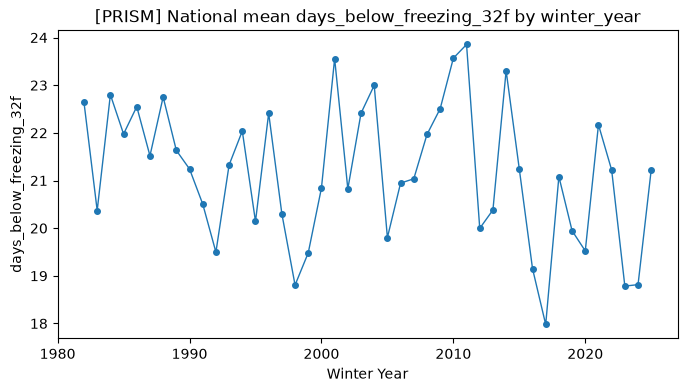

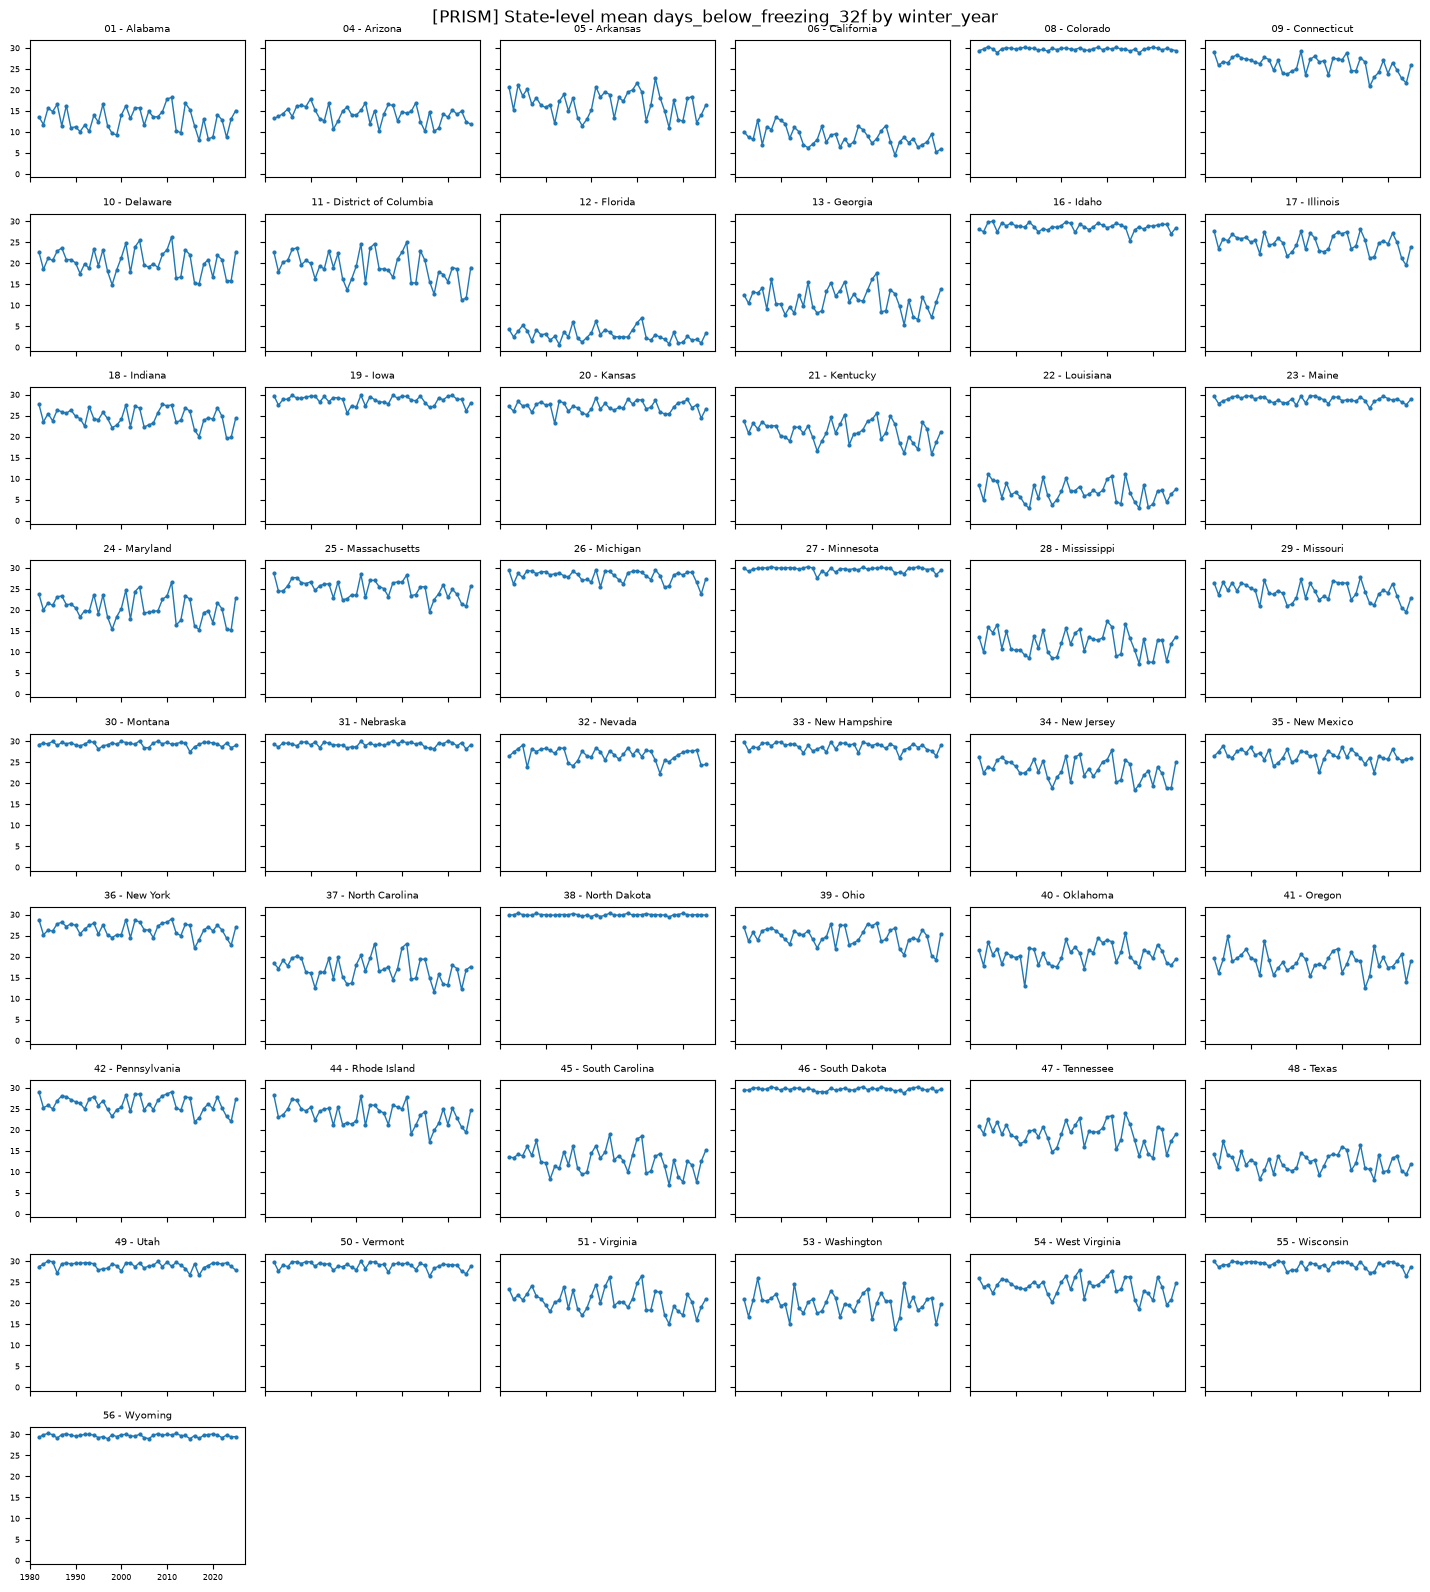

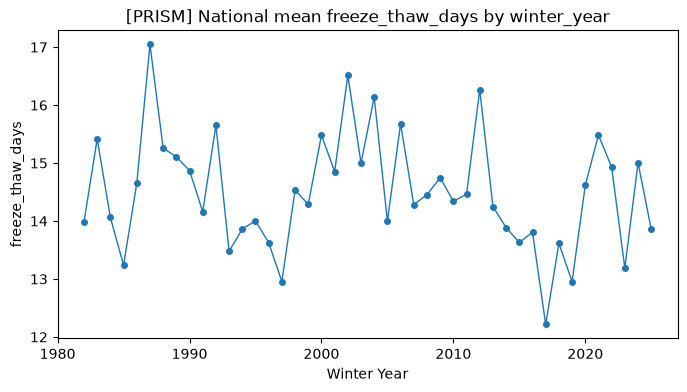

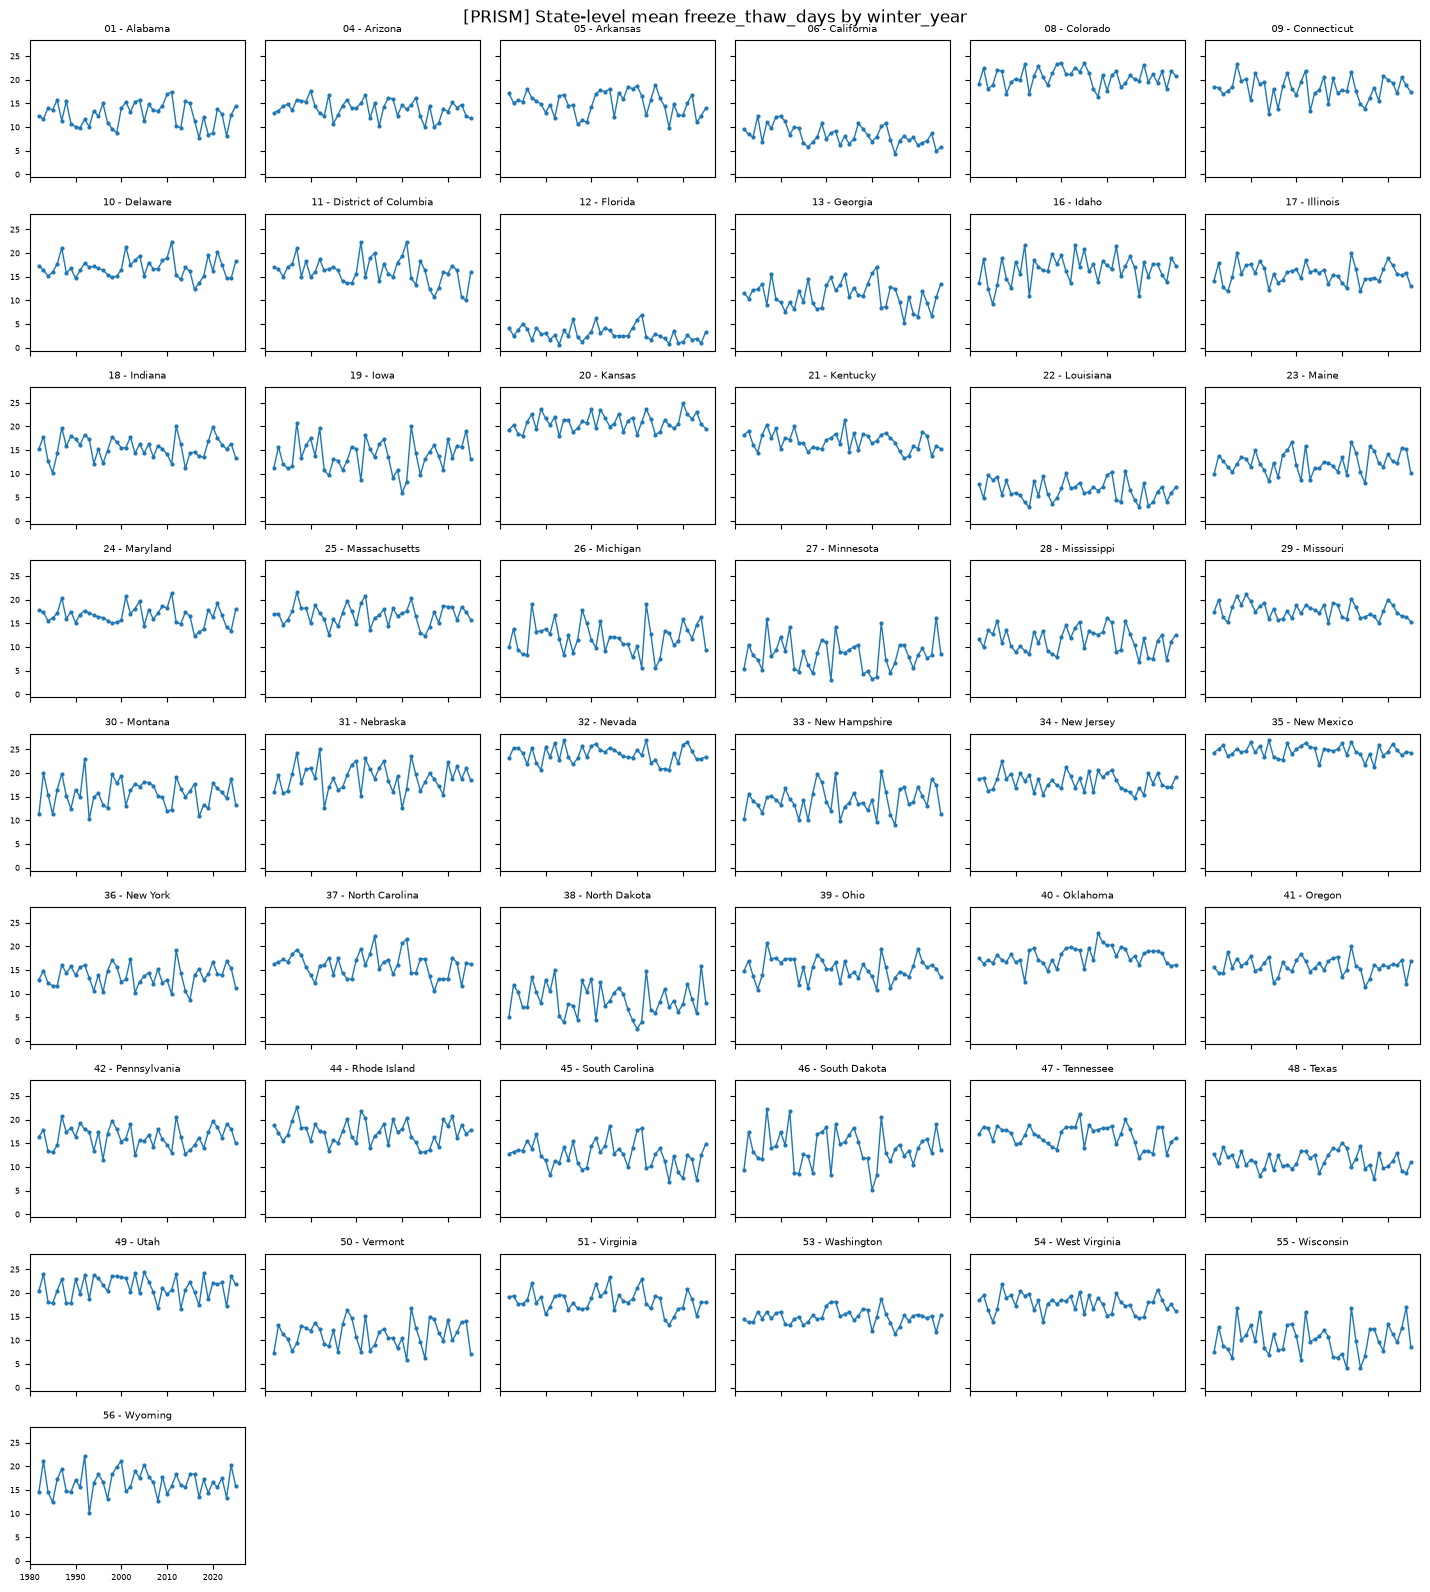

In [21]:
trend_vars = ["mean_temp_c", "days_extremely_cold", "days_below_freezing_32f", "freeze_thaw_days"]

for var in trend_vars:
    if var not in winter.columns:
        print(f"Skipping trend plots for {var!r}: not present in {config.name} panel.")
        continue
    plot_national_trend(winter, var, dataset_name=config.name)
    plot_state_small_multiples(winter, var, dataset_name=config.name)

## Per-county spaghetti plot
Single-state proof of concept (IL) below, plus the all-states multi-panel version Eyal asked for in his 8/25 Slack follow-up.

One trend line per county within a state (to eyeball within-state variation, not just a single state-aggregate line), with the state-level mean overlaid in bold and county lines drawn thin/transparent so the mean doesn't get lost in the spread -- Eyal's 8/25 refinement of the original 8/18 ask. The multi-panel figure ports his Stata `by(state_letter_code)` one-liner to Python small multiples (Wendy's existing tooling choice for Phase 4), faceting every state into one figure instead of one state at a time. If a large state's county count still makes a panel unreadable even with thin lines, that's the cue to revisit with quartile bands instead of every county.

In [ ]:
def plot_county_spaghetti_multi_panel(
    df: pd.DataFrame,
    variable: str,
    dataset_name: str,
    year_col: str = "winter_year",
    states=None,
    n_cols: int = 6,
):
    """All states in one figure, one subplot per state -- ports Eyal's
    8/25 Slack Stata one-liner (`tw line y time, connect(L)
    by(state_letter_code)`) to Python/matplotlib small multiples, per
    Wendy's existing Phase 4 tooling choice (Python, not Stata). Each
    panel reuses plot_county_spaghetti's thin/transparent county lines +
    bold state-mean overlay.
    """
    states = sorted(states) if states else sorted(df["state_fips"].unique())
    n_states = len(states)

    n_rows = -(-n_states // n_cols)  # ceil division
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(2.6 * n_cols, 2.0 * n_rows), sharex=True, sharey=True
    )
    axes = axes.flatten()

    for ax, state in zip(axes, states):
        plot_county_spaghetti(df, variable, state_fips=state, dataset_name=dataset_name, year_col=year_col, ax=ax)
        ax.tick_params(labelsize=6)

    _set_year_axis_limits(axes[0], df[year_col])  # shared axes -- setting one propagates

    for ax in axes[n_states:]:
        ax.axis("off")

    fig.suptitle(
        f"[{dataset_name}] {variable} by county, faceted by state "
        f"(thin = county, bold = state mean) -- SANITY CHECK, unstyled"
    )
    fig.tight_layout()

    out_path = FIGURES_DIR / f"{dataset_name.lower()}_sanity_county_spaghetti_multipanel_{variable}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  Saved {out_path}")
    return out_path

In [ ]:
available_states = winter["state_fips"].unique()
poc_state = (
    PROOF_OF_CONCEPT_STATE_FIPS if PROOF_OF_CONCEPT_STATE_FIPS in available_states
    else sorted(available_states)[0]
)

if "mean_temp_c" in winter.columns:
    plot_county_spaghetti(winter, "mean_temp_c", state_fips=poc_state, dataset_name=config.name)
    plot_county_spaghetti_multi_panel(winter, "mean_temp_c", dataset_name=config.name)

---

**Next steps:** switch `config` to `ERA5_CONFIG` above and re-run to see the same Tier 1 exhibits for ERA5 (secondary/robustness dataset). Tier 2 (decade distributions, anomaly frequency, choropleths) is still blocked in `09_descriptive_weather.py` pending a definition sign-off from Eyal -- not reproduced here.